In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [ ]:
model = ChatOllama(
    model="qwen3:1.7b",
)

In [4]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [7]:
graph = builder.compile(checkpointer=InMemorySaver())

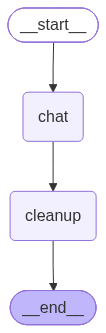

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Aman."}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='3518b33f-b12c-4537-973c-aa24f4c338b5'),
  AIMessage(content='Hello! 😊  \n**LangChain** is a powerful ecosystem of tools and libraries designed to simplify the development and deployment of large language models (LLMs) like GPT-3, GPT-4, and others. It provides a comprehensive framework for **model management**, **training**, **inference**, and **task execution**, enabling developers to build scalable, efficient, and flexible applications with LLMs.  \n\n---\n\n### 🧩 Core Components of LangChain  \n1. **LangChain Core**  \n   - The central component responsible for managing model states (e.g., weights, optimizer states, and training progress).  \n   - Handles tasks like saving checkpoints, resuming training, and evaluating models at specific steps.  \n   - Optimized for efficiency and scalability, especially for large models (e.g., 70B parameters).  \n\n2. **LangChain Connector**  \n 

In [11]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
